You are given a 2D matrix grid of size n x n. Initially, all cells of the grid are colored white. In one operation, you can select any cell of indices (i, j), and color black all the cells of the jth column starting from the top row down to the ith row.

The grid score is the sum of all grid[i][j] such that cell (i, j) is white and it has a horizontally adjacent black cell.

Return the maximum score that can be achieved after some number of operations.

 

Example 1:

Input: grid = [[0,0,0,0,0],[0,0,3,0,0],[0,1,0,0,0],[5,0,0,3,0],[0,0,0,0,2]]

Output: 11

Explanation:

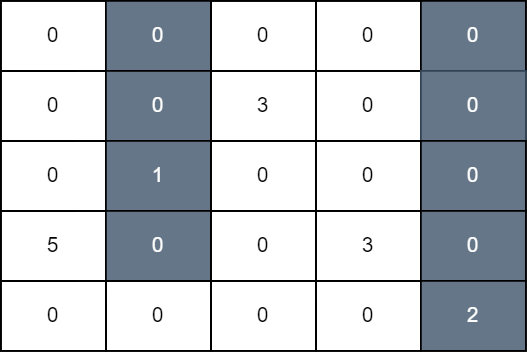

In the first operation, we color all cells in column 1 down to row 3, and in the second operation, we color all cells in column 4 down to the last row. The score of the resulting grid is grid[3][0] + grid[1][2] + grid[3][3] which is equal to 11.

Example 2:

Input: grid = [[10,9,0,0,15],[7,1,0,8,0],[5,20,0,11,0],[0,0,0,1,2],[8,12,1,10,3]]

Output: 94

Explanation:

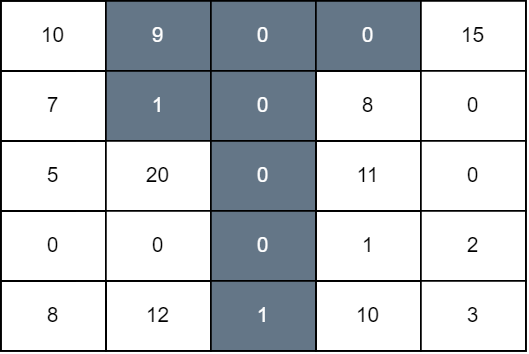

We perform operations on 1, 2, and 3 down to rows 1, 4, and 0, respectively. The score of the resulting grid is grid[0][0] + grid[1][0] + grid[2][1] + grid[4][1] + grid[1][3] + grid[2][3] + grid[3][3] + grid[4][3] + grid[0][4] which is equal to 94.

 

Constraints:

    1 <= n == grid.length <= 100
    n == grid[i].length
    0 <= grid[i][j] <= 109

 


In [ ]:
class Solution:
    def maximumScore(self, grid: List[List[int]]) -> int:
        n = len(grid[0])
        if n == 1:
            return 0

        dp = [[[0] * (n + 1) for _ in range(n + 1)] for _ in range(n)]
        prev_max = [[0] * (n + 1) for _ in range(n + 1)]
        prev_suffix_max = [[0] * (n + 1) for _ in range(n + 1)]
        col_sum = [[0] * (n + 1) for _ in range(n)]

        for c in range(n):
            for r in range(1, n + 1):
                col_sum[c][r] = col_sum[c][r - 1] + grid[r - 1][c]

        for i in range(1, n):
            for curr_h in range(n + 1):
                for prev_h in range(n + 1):
                    if curr_h <= prev_h:
                        extra_score = col_sum[i][prev_h] - col_sum[i][curr_h]
                        dp[i][curr_h][prev_h] = max(
                            dp[i][curr_h][prev_h],
                            prev_suffix_max[prev_h][0] + extra_score,
                        )
                    else:
                        extra_score = (
                            col_sum[i - 1][curr_h] - col_sum[i - 1][prev_h]
                        )
                        dp[i][curr_h][prev_h] = max(
                            dp[i][curr_h][prev_h],
                            prev_suffix_max[prev_h][curr_h],
                            prev_max[prev_h][curr_h] + extra_score,
                        )

            for curr_h in range(n + 1):
                prev_max[curr_h][0] = dp[i][curr_h][0]
                for prev_h in range(1, n + 1):
                    penalty = (
                        col_sum[i][prev_h] - col_sum[i][curr_h]
                        if prev_h > curr_h
                        else 0
                    )
                    prev_max[curr_h][prev_h] = max(
                        prev_max[curr_h][prev_h - 1],
                        dp[i][curr_h][prev_h] - penalty,
                    )

                prev_suffix_max[curr_h][n] = dp[i][curr_h][n]
                for prev_h in range(n - 1, -1, -1):
                    prev_suffix_max[curr_h][prev_h] = max(
                        prev_suffix_max[curr_h][prev_h + 1],
                        dp[i][curr_h][prev_h],
                    )

        ans = 0
        for k in range(n + 1):
            ans = max(ans, dp[n - 1][n][k], dp[n - 1][0][k])

        return ans